# Mini Project:
## **Student Segmentation**

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Create the Dataset
data = {
    "Student": [
        "Student_1", "Student_2", "Student_3", "Student_4",
        "Student_5", "Student_6", "Student_7", "Student_8",
        "Student_9", "Student_10", "Student_11", "Student_12",
        "Student_13", "Student_14", "Student_15"
    ],

    "Study_Hours": [
        1.5, 2.0, 2.5, 3.0, 3.5,
        4.0, 4.5, 5.0, 5.5, 6.0,
        6.5, 7.0, 7.5, 8.0, 8.5
    ],

    "Quiz_Score": [
        40, 45, 48, 52, 55,
        60, 64, 68, 72, 76,
        80, 84, 87, 91, 94
    ],

    "Attendance": [
        55, 60, 62, 65, 68,
        70, 73, 76, 80, 82,
        85, 88, 90, 93, 95
    ]
}

df = pd.DataFrame(data)

df.head()

,Student,Study_Hours,Quiz_Score,Attendance
0,Student_1,1.5,40,55
1,Student_2,2.0,45,60
2,Student_3,2.5,48,62
3,Student_4,3.0,52,65
4,Student_5,3.5,55,68


In [3]:
# Select Features for Clustering

X = df[
    [
        "Study_Hours",
        "Quiz_Score",
        "Attendance"
    ]
]

# Standardize the Data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##  Apply K-Means Clustering

In [4]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df

c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Student,Study_Hours,Quiz_Score,Attendance,Cluster
0,Student_1,1.5,40,55,1
1,Student_2,2.0,45,60,1
2,Student_3,2.5,48,62,1
3,Student_4,3.0,52,65,1
4,Student_5,3.5,55,68,1
5,Student_6,4.0,60,70,1
6,Student_7,4.5,64,73,2
7,Student_8,5.0,68,76,2
8,Student_9,5.5,72,80,2
9,Student_10,6.0,76,82,2


## Calculate Cluster Profiles

In [5]:
cluster_profile = df.groupby("Cluster")[
    [
        "Study_Hours",
        "Quiz_Score",
        "Attendance"
    ]
].mean()

cluster_profile

,Study_Hours,Quiz_Score,Attendance
Cluster,,,
0,7.50,87.2,90.200000
1,2.75,50.0,63.333333
2,5.25,70.0,77.750000


In [7]:
# Sort the Clusters by Study Hours
cluster_profile = cluster_profile.sort_values("Study_Hours")
cluster_profile

,Study_Hours,Quiz_Score,Attendance
Cluster,,,
1,2.75,50.0,63.333333
2,5.25,70.0,77.750000
0,7.50,87.2,90.200000


In [ ]:
# Create Meaningful Cluster Names
sorted_clusters = cluster_profile.index.tolist()
cluster_names = {
    sorted_clusters[0]: "Low Engagement",
    sorted_clusters[1]: "Moderate Engagement",
    sorted_clusters[2]: "High Engagement"
}

df["Cluster_Profile"] = df["Cluster"].map(cluster_names)
df.head()

,Student,Study_Hours,Quiz_Score,Attendance,Cluster,Cluster_Profile
0,Student_1,1.5,40,55,1,Low Engagement
1,Student_2,2.0,45,60,1,Low Engagement
2,Student_3,2.5,48,62,1,Low Engagement
3,Student_4,3.0,52,65,1,Low Engagement
4,Student_5,3.5,55,68,1,Low Engagement


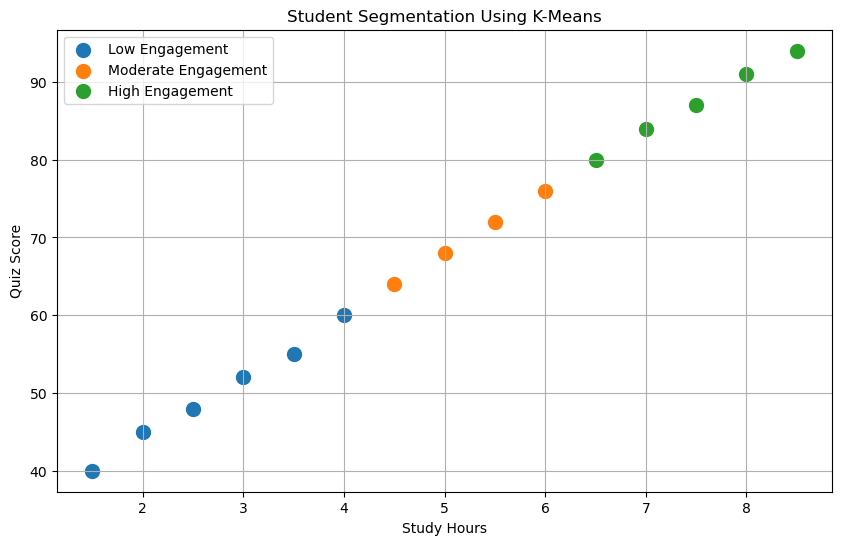

In [8]:
# Visualize the Clusters
plt.figure(figsize=(10, 6))

for cluster in df["Cluster"].unique():

    cluster_data = df[df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Study_Hours"],
        cluster_data["Quiz_Score"],
        label=cluster_names[cluster],
        s=100
    )

plt.xlabel("Study Hours")
plt.ylabel("Quiz Score")
plt.title("Student Segmentation Using K-Means")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
# Display Final Cluster Profiles

for cluster in sorted_clusters:

    profile = cluster_profile.loc[cluster]

    print(
        f"{cluster_names[cluster]}: "
        f"average study time = {profile['Study_Hours']:.1f} hours, "
        f"average quiz score = {profile['Quiz_Score']:.1f}, "
        f"average attendance = {profile['Attendance']:.1f}%."
    )

Low Engagement: average study time = 2.8 hours, average quiz score = 50.0, average attendance = 63.3%.
Moderate Engagement: average study time = 5.2 hours, average quiz score = 70.0, average attendance = 77.8%.
High Engagement: average study time = 7.5 hours, average quiz score = 87.2, average attendance = 90.2%.


In [13]:
# ONE-LINE CLUSTER PROFILES
for cluster in sorted_clusters:

    profile = cluster_profile.loc[cluster]
    print(
        f"{cluster_names[cluster]}: "
        f"Students with approximately {profile['Study_Hours']:.1f} study hours, "
        f"{profile['Quiz_Score']:.1f} quiz score, and "
        f"{profile['Attendance']:.1f}% attendance."
    )

Low Engagement: Students with approximately 2.8 study hours, 50.0 quiz score, and 63.3% attendance.
Moderate Engagement: Students with approximately 5.2 study hours, 70.0 quiz score, and 77.8% attendance.
High Engagement: Students with approximately 7.5 study hours, 87.2 quiz score, and 90.2% attendance.


## Find the Best Number of Clusters

c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\sklearn\c

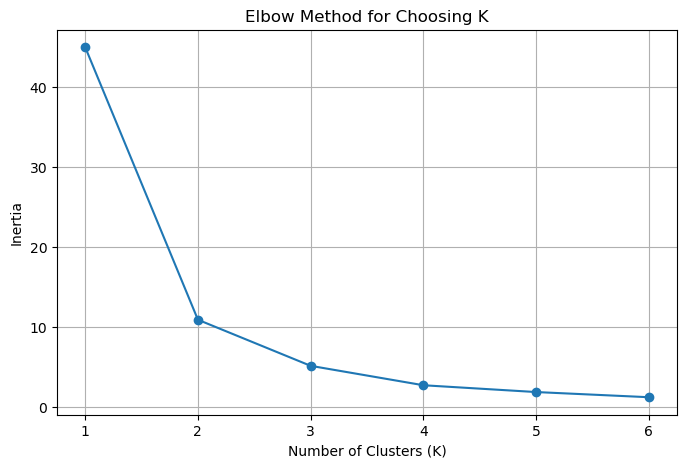

In [ ]:
inertias = []
for k in range(1, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot( range(1, 7), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")

plt.grid(True)
plt.show()